In [ ]:
!pip install timm -q


In [4]:
import os
import zipfile
from PIL import Image
import zipfile

import matplotlib.pyplot as plt

In [5]:
!wget -O /kaggle/working/mosquito_dataset.zip "https://zenodo.org/records/14238701/files/mosquito-dataset-for-classification-cnn.zip?download=1"

--2026-07-04 11:29:03--  https://zenodo.org/records/14238701/files/mosquito-dataset-for-classification-cnn.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.184.98.114, 137.138.52.235, 188.185.48.75, ...
Connecting to zenodo.org (zenodo.org)|188.184.98.114|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 56823727 (54M) [application/octet-stream]
Saving to: ‘/kaggle/working/mosquito_dataset.zip’

/kaggle/working/mos 100%[===================>]  54.19M  18.3MB/s    in 3.0s    

2026-07-04 11:29:07 (18.3 MB/s) - ‘/kaggle/working/mosquito_dataset.zip’ saved [56823727/56823727]



In [6]:
with zipfile.ZipFile("/kaggle/working/mosquito_dataset.zip", "r") as zip_ref:
    zip_ref.extractall("/kaggle/working/Dataset")

In [7]:
root_dir = "/kaggle/working/Dataset/Mosquito_dataset"


In [8]:
os.listdir(root_dir)

['CULEX', 'AEDES', 'ANOPHELES']

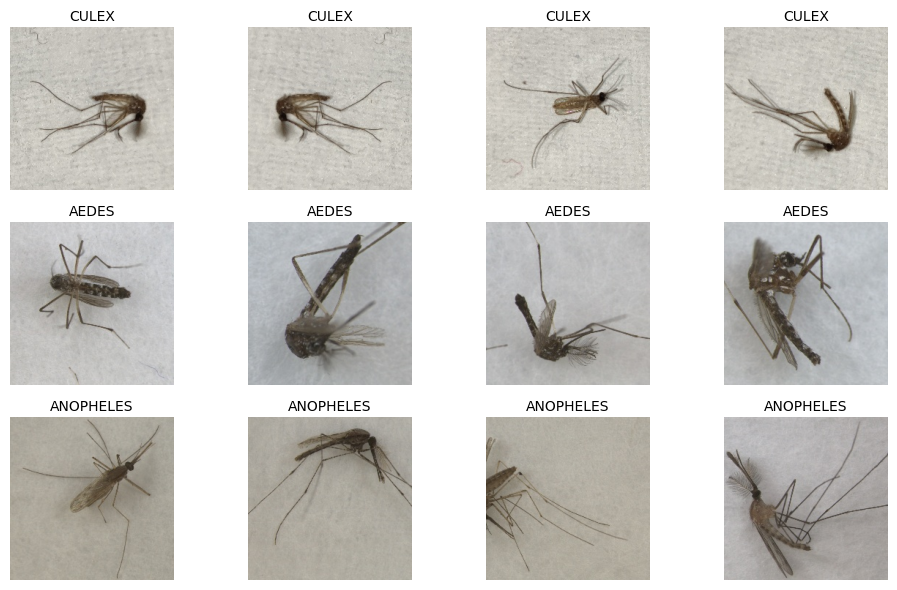

In [9]:
fig, axes = plt.subplots(3, 4, figsize=(10, 6) )
axes_flat = axes.flatten()
axes_id = 0
for file in os.listdir(root_dir):
    class_type = os.path.join(root_dir, file)
    for index,img in enumerate(os.listdir(class_type)[:4]):
        image_path = os.path.join(class_type, img)
        with Image.open(image_path) as im:
            axes_flat[axes_id].imshow(im)
            axes_flat[axes_id].axis("off")
            axes_flat[axes_id].set_title(file, fontsize=10, pad=4) 
            axes_id +=1

plt.tight_layout()
plt.show()

In [33]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.RandomRotation(degrees= 360),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Clean resize only
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [34]:
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split, DataLoader

base_dataset = ImageFolder(root="/kaggle/working/Dataset/Mosquito_dataset")

train_size = int(0.8 * len(data_folder))
val_size = len(data_folder) - train_size

train_data, val_data = random_split(data_folder, [train_size, val_size])

class DatasetSubsetWrapper:
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.subset)


In [35]:
train_dataset_full = ImageFolder(root="/kaggle/working/Dataset/Mosquito_dataset", transform=train_transforms)
val_dataset_full = ImageFolder(root="/kaggle/working/Dataset/Mosquito_dataset", transform=val_transforms)

dataset_size = len(train_dataset_full)
indices = list(range(dataset_size))
split = int(0.8 * dataset_size)

np.random.seed(42)
np.random.shuffle(indices)

train_idx, val_idx = indices[:split], indices[split:]

train_data = Subset(train_dataset_full, train_idx)
val_data = Subset(val_dataset_full, val_idx)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

print(f"Data split perfectly! Train samples: {len(train_data)}, Val samples: {len(val_data)}")

Data split perfectly! Train samples: 2400, Val samples: 600


In [36]:
import timm
import torch 
import torch.nn as nn

model = timm.create_model("vit_tiny_patch16_224", pretrained = True)

print(model.head)

Linear(in_features=192, out_features=1000, bias=True)


In [37]:
model.head = nn.Linear(model.head.in_features, 3)
print(model.head)

Linear(in_features=192, out_features=3, bias=True)


In [38]:
device = torch.device("cuda")
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr= 3e-4)

In [ ]:
import time

num_epochs = 30
model = model.to(device)
for epoch in range(num_epochs):
    start_time = time.time()

    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0


    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = (correct_train / total_train) * 100 

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100
    
    elapsed_time = time.time() - start_time
    
    # Print the progress for this epoch
    print(f"Epoch [{epoch+1}/{num_epochs}] ({elapsed_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% || "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}%")

Epoch [1/30] (15.6s) -> Train Loss: 0.4885 | Train Acc: 86.04% || Val Loss: 0.1841 | Val Acc: 92.67%
Epoch [2/30] (15.2s) -> Train Loss: 0.0522 | Train Acc: 97.83% || Val Loss: 0.0161 | Val Acc: 99.33%
Epoch [3/30] (14.5s) -> Train Loss: 0.0397 | Train Acc: 98.62% || Val Loss: 0.0392 | Val Acc: 98.83%
Epoch [4/30] (14.2s) -> Train Loss: 0.0576 | Train Acc: 98.04% || Val Loss: 0.0244 | Val Acc: 99.17%
Epoch [5/30] (14.3s) -> Train Loss: 0.1504 | Train Acc: 95.33% || Val Loss: 0.2296 | Val Acc: 93.33%
Epoch [6/30] (14.6s) -> Train Loss: 0.0346 | Train Acc: 98.92% || Val Loss: 0.0129 | Val Acc: 99.83%
Epoch [7/30] (15.0s) -> Train Loss: 0.0434 | Train Acc: 98.54% || Val Loss: 0.0189 | Val Acc: 99.17%
